# NB_15_trial_comparison - Trial Comparison - Validation / Test Aggregates

**Purpose.** Aggregate every run across every trial in the val and test partitions and produce the closed-loop comparison tables and figures used in section 6 of the thesis: route plots coloured by risk and ego speed, efficiency bar charts, and 3x3 comparison videos.

**Inputs.** all runs/ folders produced by NB_10-13.

**Outputs.** per-trial CSVs, route plots, efficiency bar charts, aggregate summary tables, comparison videos.

**How to run.** Run top-to-bottom. Sections 7-8 control the composite-metric parameters; section 9 toggles video rendering.

**Position in the workflow.** Final aggregate analysis stage. Consumes NB_10-13 output.


## 1 — Imports

In [1]:
import csv
import json
from pathlib import Path

from IPython.display import Video, display

from MIREIA.analysis.trial_comparison import (
    RUN_GRID_LAYOUT,
    RUN_PREFIXES,
    TEST_MAP_NAMES,
    TEST_VAL_MAP_NAMES,
    VAL_MAP_NAMES,
    aggregate_by_prefix,
    classify_trial_split,
    compute_run_metrics,
    compute_trial_metrics_table,
    discover_trial_runs,
    is_test_or_val_trial,
    render_aggregate_efficiency_barplot,
    render_comparison_video,
    render_efficiency_barplot,
    render_route_grid,
)
from MIREIA.config import Config

print('Imports ready.')
print(f'Val maps:  {VAL_MAP_NAMES}')
print(f'Test maps: {TEST_MAP_NAMES}')
print(f'Prefixes:  {RUN_PREFIXES}')

Imports ready.
Val maps:  ('Town05',)
Test maps: ('Town10HD',)
Prefixes:  ('base', 'e2e', 'composed', 'half_slow', 'slow', 'very_slow', 'riskfn1', 'riskfn2', 'riskfn3', 'riskfn4', 'riskfn5')


## 2 — Discover Val + Test Trials
Lists every saved `TrialDefinition` whose map is in the val (`Town05`) or test (`Town10HD`) splits. Adjust `INCLUDE_REGEX` / `EXCLUDE_TRIALS` to narrow the comparison. The split (val/test) for each trial is recorded in `trial_split` so §8 can render aggregates per split.

In [2]:
import re

trials_root = Path(Config.PATH_TO_TRIALS)
all_trial_dirs = sorted(p.parent for p in trials_root.glob('*/trial.json') if p.is_file())

INCLUDE_REGEX: str | None = None       # e.g. r'Town10HD' to only keep test trials
EXCLUDE_TRIALS: list[str] = []         # exact trial names to skip

selected_trial_dirs: list[Path] = []
trial_split: dict[str, str] = {}       # trial_name -> 'val' | 'test'
for tdir in all_trial_dirs:
    trial_meta = json.loads((tdir / 'trial.json').read_text(encoding='utf-8'))
    map_name = str(trial_meta.get('map_name', ''))
    split = classify_trial_split(tdir.name, map_name=map_name)
    if split is None:
        continue
    if INCLUDE_REGEX and not re.search(INCLUDE_REGEX, tdir.name):
        continue
    if tdir.name in EXCLUDE_TRIALS:
        continue
    selected_trial_dirs.append(tdir)
    trial_split[tdir.name] = split

n_val  = sum(1 for s in trial_split.values() if s == 'val')
n_test = sum(1 for s in trial_split.values() if s == 'test')
print(f'All trials: {len(all_trial_dirs)};  selected: {len(selected_trial_dirs)} (val={n_val}, test={n_test})')
for tdir in selected_trial_dirs:
    print(f'  [{trial_split[tdir.name]:<4}] {tdir.name}')

All trials: 20;  selected: 20 (val=10, test=10)
  [val ] auto_17A_WetNoon_Town05_HighVol
  [val ] auto_17B_WetNoon_Town05_LowVol
  [test] auto_17C_WetNoon_Town10HD_HighVol
  [test] auto_17D_WetNoon_Town10HD_LowVol
  [val ] auto_18A_MidRainyNoon_Town05_HighVol
  [val ] auto_18B_MidRainyNoon_Town05_LowVol
  [test] auto_18C_MidRainyNoon_Town10HD_HighVol
  [test] auto_18D_MidRainyNoon_Town10HD_LowVol
  [val ] auto_19A_CloudySunset_Town05_HighVol
  [val ] auto_19B_CloudySunset_Town05_LowVol
  [test] auto_19C_CloudySunset_Town10HD_HighVol
  [test] auto_19D_CloudySunset_Town10HD_LowVol
  [val ] auto_20A_SoftRainSunset_Town05_HighVol
  [val ] auto_20B_SoftRainSunset_Town05_LowVol
  [test] auto_20C_SoftRainSunset_Town10HD_HighVol
  [test] auto_20D_SoftRainSunset_Town10HD_LowVol
  [val ] auto_21A_ClearNoon_Town05_HighVol_NoFog_Night
  [val ] auto_21B_CloudyNoon_Town05_LowVol_NoFog_Night
  [test] auto_21C_WetNoon_Town10HD_HighVol_NoFog_Night
  [test] auto_21D_HardRainNoon_Town10HD_LowVol_NoFog_Ni

## 3 — Load Runs Per Trial
`discover_trial_runs` walks `runs/<timestamp>_<prefix>/` for every recognised prefix and returns the **latest** one (sorted by folder name, which starts with `YYYYMMDD_HHMMSS_`). Missing prefixes come back as `None` so the rest of the pipeline can leave them blank.

In [3]:
runs_by_trial: dict[str, dict] = {}

for tdir in selected_trial_dirs:
    runs = discover_trial_runs(tdir)
    runs_by_trial[tdir.name] = runs
    available = [p for p, rd in runs.items() if rd is not None]
    missing   = [p for p, rd in runs.items() if rd is None]
    print(f'{tdir.name:55s} have={available}  missing={missing}')

auto_17A_WetNoon_Town05_HighVol                         have=['base', 'e2e', 'composed', 'half_slow', 'slow', 'very_slow', 'riskfn1', 'riskfn2', 'riskfn3', 'riskfn4', 'riskfn5']  missing=[]
auto_17B_WetNoon_Town05_LowVol                          have=['base', 'e2e', 'composed', 'half_slow', 'slow', 'very_slow', 'riskfn1', 'riskfn2', 'riskfn3', 'riskfn4', 'riskfn5']  missing=[]
auto_17C_WetNoon_Town10HD_HighVol                       have=['base', 'e2e', 'composed', 'half_slow', 'slow', 'very_slow', 'riskfn1', 'riskfn2', 'riskfn3', 'riskfn4', 'riskfn5']  missing=[]
auto_17D_WetNoon_Town10HD_LowVol                        have=['base', 'e2e', 'composed', 'half_slow', 'slow', 'very_slow', 'riskfn1', 'riskfn2', 'riskfn3', 'riskfn4', 'riskfn5']  missing=[]
auto_18A_MidRainyNoon_Town05_HighVol                    have=['base', 'e2e', 'half_slow', 'slow', 'very_slow', 'riskfn1', 'riskfn2', 'riskfn3', 'riskfn4', 'riskfn5']  missing=['composed']
auto_18B_MidRainyNoon_Town05_LowVol                 

## 4 — Data Summary Tables
Two tables:

1. **Per-trial / per-prefix** — every (trial, prefix) row with full metrics. Also written to `<trial>/comparison/metrics.csv` and a combined `<PATH_TO_TRIALS>/comparison_summary.csv`.
2. **Cross-trial mean/median per prefix** — aggregate over the test+val set so you can compare prefixes head-to-head.

Metric definitions:

- `total_distance_m`  — sum of per-segment ego XY displacements.
- `total_sim_time_s`  — `n_frames * fixed_delta * image_stride`.
- `risk_per_meter`    — `∫ risk(s) ds / total_distance` (trapezoidal in **distance**, not time — lets you compare runs of unequal duration).
- `risk_auc`          — same risk integrated in **time** (km/h·s units), kept for reference.
- `avg_speed_kmh` / `max_speed_kmh` / `speed_std_kmh` — from `ego.speed * 3.6`.

In [4]:
PER_TRIAL_CSV_COLS = (
    'trial', 'prefix', 'available', 'n_frames',
    'total_distance_m', 'total_sim_time_s',
    'avg_speed_kmh', 'max_speed_kmh', 'speed_std_kmh',
    'risk_auc', 'risk_per_meter', 'mean_risk', 'max_risk',
)

rows = compute_trial_metrics_table(runs_by_trial)

# Per-trial pretty print + per-trial CSV.
for tdir in selected_trial_dirs:
    trial_rows = [r for r in rows if r['trial'] == tdir.name]
    print()
    print(f'=== {tdir.name} ===')
    print(f"  {'prefix':10s} {'n_frames':>8s} {'dist_m':>9s} {'time_s':>8s} {'avg_kmh':>8s} {'max_kmh':>8s} {'risk_auc':>9s} {'risk/m':>9s}")
    for r in trial_rows:
        marker = '  ' if r['available'] else '· '
        print(
            f"{marker}{r['prefix']:10s} {r['n_frames']:>8d} {r['total_distance_m']:>9.1f} "
            f"{r['total_sim_time_s']:>8.1f} {r['avg_speed_kmh']:>8.2f} {r['max_speed_kmh']:>8.2f} "
            f"{r['risk_auc']:>9.3f} {r['risk_per_meter']:>9.4f}"
        )

    cmp_dir = tdir / 'comparison'
    cmp_dir.mkdir(parents=True, exist_ok=True)
    with open(cmp_dir / 'metrics.csv', 'w', encoding='utf-8', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=PER_TRIAL_CSV_COLS)
        writer.writeheader()
        for r in trial_rows:
            writer.writerow({k: r.get(k, '') for k in PER_TRIAL_CSV_COLS})

# Combined CSV across every (trial, prefix).
combined_csv = trials_root / 'comparison_summary.csv'
with open(combined_csv, 'w', encoding='utf-8', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=PER_TRIAL_CSV_COLS)
    writer.writeheader()
    for r in rows:
        writer.writerow({k: r.get(k, '') for k in PER_TRIAL_CSV_COLS})
print(f'\nWrote combined CSV: {combined_csv}')

# Cross-trial aggregation per prefix (mean + median across available runs).
print()
print('=== Cross-trial aggregation per prefix (test+val) ===')
agg = aggregate_by_prefix(rows)
print(f"  {'prefix':10s} {'n':>3s} {'dist_m̄':>10s} {'time_s̄':>9s} {'v̄_kmh':>8s} {'risk/m̄':>10s} {'risk/m ̃':>10s}")
for a in agg:
    print(
        f"  {a['prefix']:10s} {a['n_runs']:>3d} "
        f"{a['total_distance_m_mean']:>10.1f} {a['total_sim_time_s_mean']:>9.1f} "
        f"{a['avg_speed_kmh_mean']:>8.2f} {a['risk_per_meter_mean']:>10.4f} {a['risk_per_meter_median']:>10.4f}"
    )


=== auto_17A_WetNoon_Town05_HighVol ===
  prefix     n_frames    dist_m   time_s  avg_kmh  max_kmh  risk_auc    risk/m
  base            282     551.8     70.5    20.28    86.62   171.706    2.7149
  e2e             396     544.5     99.0    19.90    86.62   238.993    2.5918
  composed        394     549.5     98.5    20.19    86.67   237.058    2.6591
  half_slow       399     544.8     99.8    19.76    76.58   236.720    2.6076
  slow            424     549.7    106.0    18.75    58.94   241.621    2.3373
  very_slow       624     537.7    156.0    12.44    40.42   310.111    2.0599
  riskfn1         394     549.6     98.5    20.20    86.66   243.059    2.6501
  riskfn2         394     547.0     98.5    20.11    86.67   241.984    2.6795
  riskfn3         394     547.5     98.5    20.13    86.74   246.911    2.4485
  riskfn4         394     549.1     98.5    20.18    86.71   244.631    2.5582
  riskfn5         395     548.3     98.8    20.10    86.63   253.178    2.5152

=== auto_1

## 5 — Route Plots Colored by Ground-Truth Risk
One static figure per trial. Each panel draws the ego `(x, y)` trajectory colored by `ground_truth_risk` at that point along the route; brighter / yellower segments = higher risk. Missing prefixes show `(no run)` and stay blank. Saved to `<trial>/comparison/route_by_risk.png`.

Set `SHOW_FIGURES_5 = False` to skip inline display (PNGs are still written to disk).

In [5]:
import matplotlib.pyplot as plt

SHOW_FIGURES_5 = False    # toggle inline display (PNGs always saved to disk)

for tdir in selected_trial_dirs:
    cmp_dir = tdir / 'comparison'
    cmp_dir.mkdir(parents=True, exist_ok=True)
    fig = render_route_grid(
        runs_by_trial[tdir.name],
        color_by='risk_gt',
        title=f'[{trial_split[tdir.name]}] {tdir.name}  —  route colored by ground-truth risk',
        output_path=cmp_dir / 'route_by_risk.png',
        cmap_name='viridis',
    )
    if SHOW_FIGURES_5:
        plt.show()
    plt.close(fig)
print(f'Saved route_by_risk.png for {len(selected_trial_dirs)} trial(s).  shown_inline={SHOW_FIGURES_5}')

Saved route_by_risk.png for 20 trial(s).  shown_inline=False


## 6 — Route Plots Colored by Ego Speed
Same layout but colored by the actual ego speed (`ego.speed * 3.6` km/h). This makes it easy to spot where each policy slows down: slow / half_slow / very_slow should be uniformly dim, while e2e / composed / riskfn* should brighten in low-risk zones and dim in dense traffic. Saved to `<trial>/comparison/route_by_speed.png`.

Set `SHOW_FIGURES_6 = False` to skip inline display (PNGs are still written to disk).

In [6]:
SHOW_FIGURES_6 = False    # toggle inline display (PNGs always saved to disk)

for tdir in selected_trial_dirs:
    cmp_dir = tdir / 'comparison'
    cmp_dir.mkdir(parents=True, exist_ok=True)
    fig = render_route_grid(
        runs_by_trial[tdir.name],
        color_by='speed_kmh',
        title=f'[{trial_split[tdir.name]}] {tdir.name}  —  route colored by ego speed',
        output_path=cmp_dir / 'route_by_speed.png',
        cmap_name='plasma',
    )
    if SHOW_FIGURES_6:
        plt.show()
    plt.close(fig)
print(f'Saved route_by_speed.png for {len(selected_trial_dirs)} trial(s).  shown_inline={SHOW_FIGURES_6}')

Saved route_by_speed.png for 20 trial(s).  shown_inline=False


## 7 — Efficiency Bar Charts

For each trial: a **2×3** bar chart comparing every prefix to the **base** run. All deltas are **plain percentages** of the base-run value.

**Row 0 — core speed/risk:**

| Panel | Metric | Green when |
|-------|--------|-----------|
| col 0 | `% Δ risk/m` | risk went down |
| col 1 | `% Δ time` | time went down |
| col 2 | `(% Δ risk/m) ÷ (% Δ time)` | risk dropped faster than time grew |

**Row 1 — composite cost / utility scores (also expressed as % Δ vs. base):**

| Panel | Underlying score | Green when |
|-------|------------------|-----------|
| col 0 | `J = w_time·T + w_risk·∫R ds`  (Economic Cost) | J went down (cheaper) |
| col 1 | `Score = exp(−α·T) / ∫R ds`  (Safety-Utility) | Score went up (safer & faster) |
| col 2 | `Throughput = D / (T·(1 + β·R̄))`  (Risk-Adjusted) | Throughput went up |

Tune `W_TIME`, `W_RISK`, `ALPHA`, `BETA` in the config cell below; the values are shared with §8. X-tick labels are **green** if the run finished, **red** if it did not.

In [7]:
# ── Composite-metric parameters (shared by §7 and §8) ──────────────────
W_TIME = 1.0    # Economic Cost J: weight on total sim time (seconds)
W_RISK = 2.0    # Economic Cost J: weight on integral of risk over distance
ALPHA  = 0.01   # Safety-Utility Score: exponential decay rate (per second)
BETA   = 0.5    # Risk-Adjusted Throughput: risk penalty multiplier

print(f"J        = {W_TIME}*T + {W_RISK}*integral(R ds)")
print(f"Score    = exp(-{ALPHA}*T) / integral(R ds)")
print(f"Tput     = D / (T * (1 + {BETA}*R_mean))")

J        = 1.0*T + 2.0*integral(R ds)
Score    = exp(-0.01*T) / integral(R ds)
Tput     = D / (T * (1 + 0.5*R_mean))


In [8]:
import matplotlib.pyplot as plt

SHOW_FIGURES_7 = False    # toggle inline display (PNGs always saved to disk)

for tdir in selected_trial_dirs:
    cmp_dir = tdir / 'comparison'
    cmp_dir.mkdir(parents=True, exist_ok=True)
    fig = render_efficiency_barplot(
        runs_by_trial[tdir.name],
        title=f'[{trial_split[tdir.name]}] {tdir.name}  —  efficiency vs. base',
        output_path=cmp_dir / 'efficiency.png',
        w_time=W_TIME, w_risk=W_RISK, alpha=ALPHA, beta=BETA,
    )
    if SHOW_FIGURES_7:
        plt.show()
    plt.close(fig)
print(f'Saved efficiency.png for {len(selected_trial_dirs)} trial(s).  shown_inline={SHOW_FIGURES_7}')

Saved efficiency.png for 20 trial(s).  shown_inline=False


## 8 — Aggregate Efficiency Summary (Val / Test / Val + Test)

Same 2×3 layout as §7 but averaged across trials. Each bar is the mean % change vs. that trial's own base run, so the metric is scale-invariant (high-risk and low-risk scenarios contribute equally). Bar annotations show how many trials contributed.

Three plots are produced and saved to `<PATH_TO_TRIALS>/comparison/`:

- `aggregate_efficiency_val.png`     — only validation trials (`Town05`)
- `aggregate_efficiency_test.png`    — only test trials (`Town10HD`)
- `aggregate_efficiency_all.png`     — both splits combined

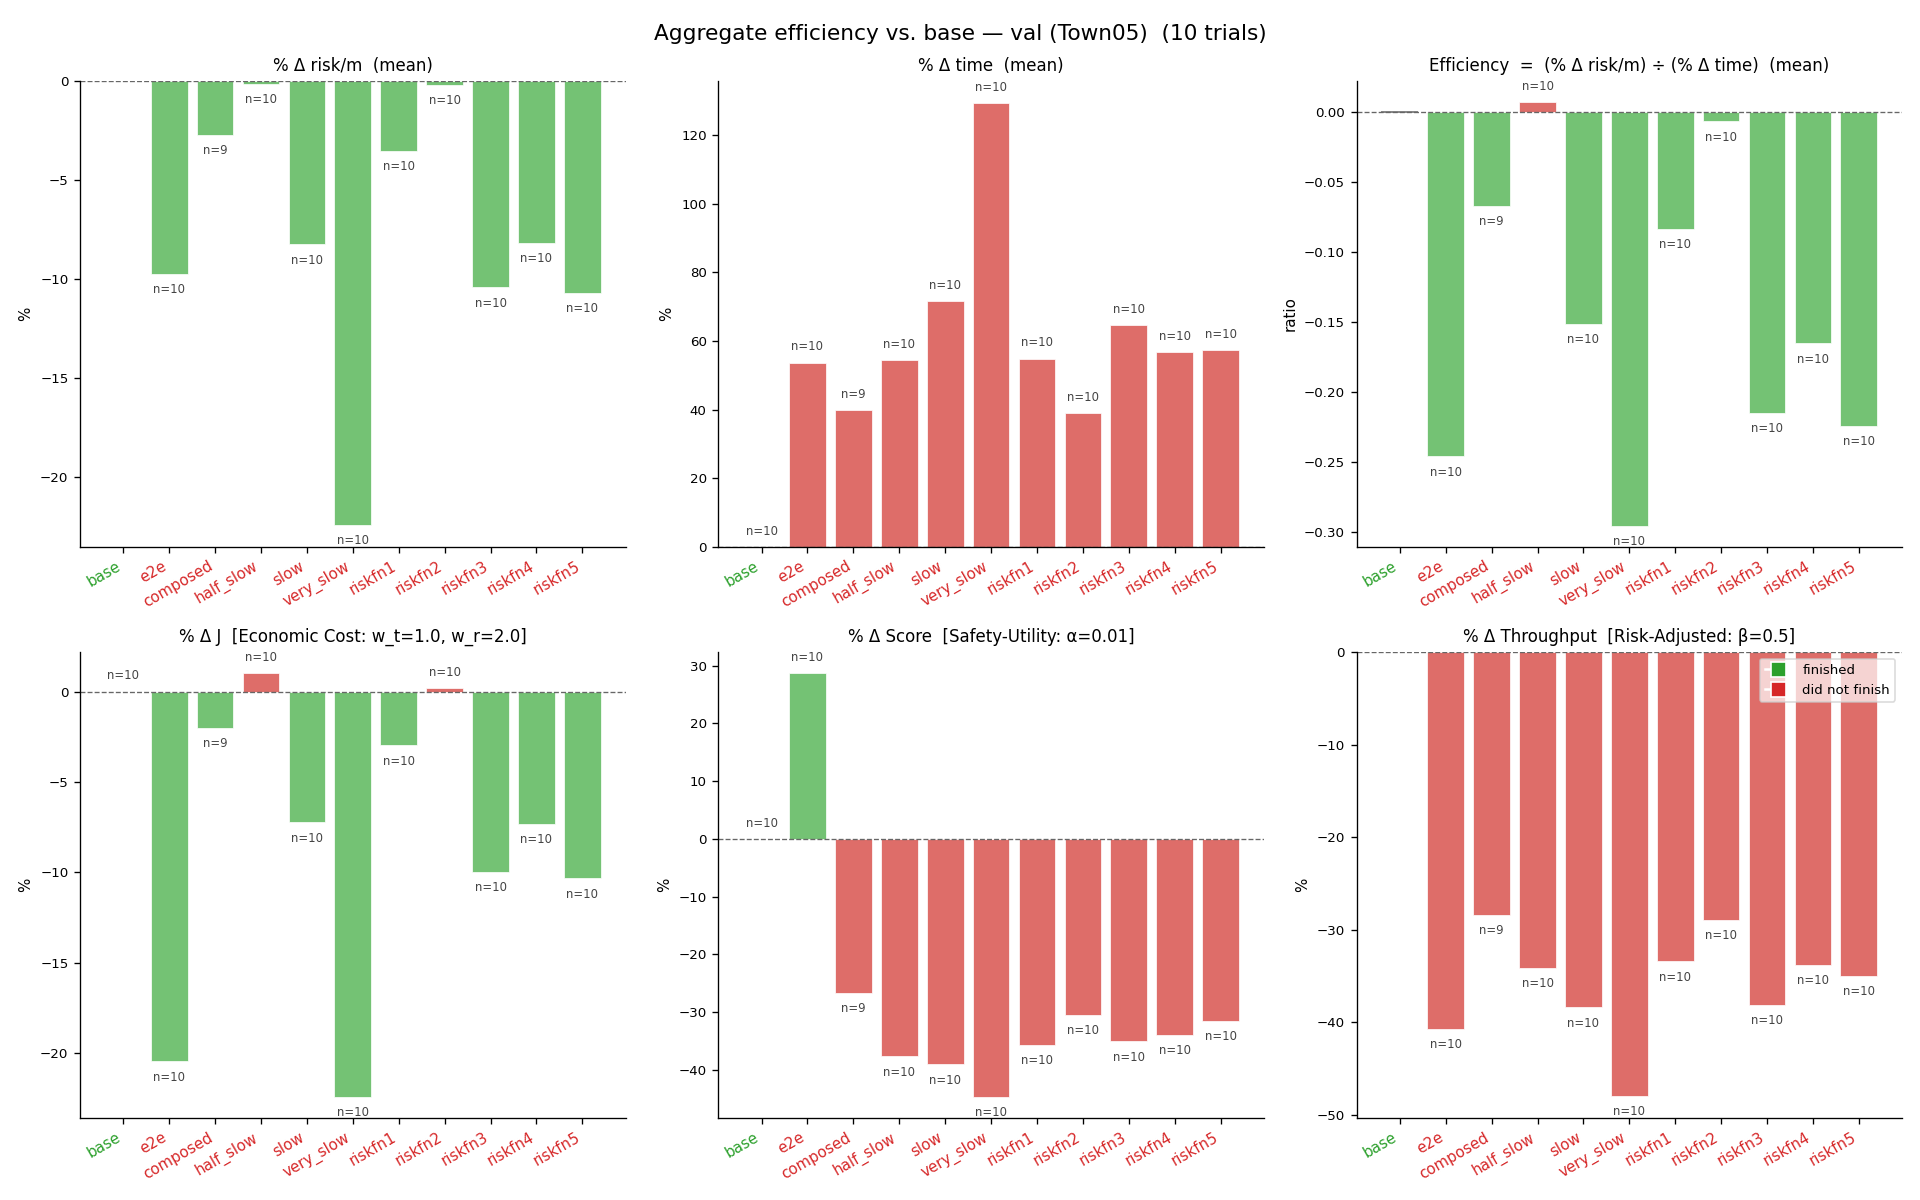

[val ] 10 trials -> t:\TFG\MIREIA\trials\comparison\aggregate_efficiency_val.png


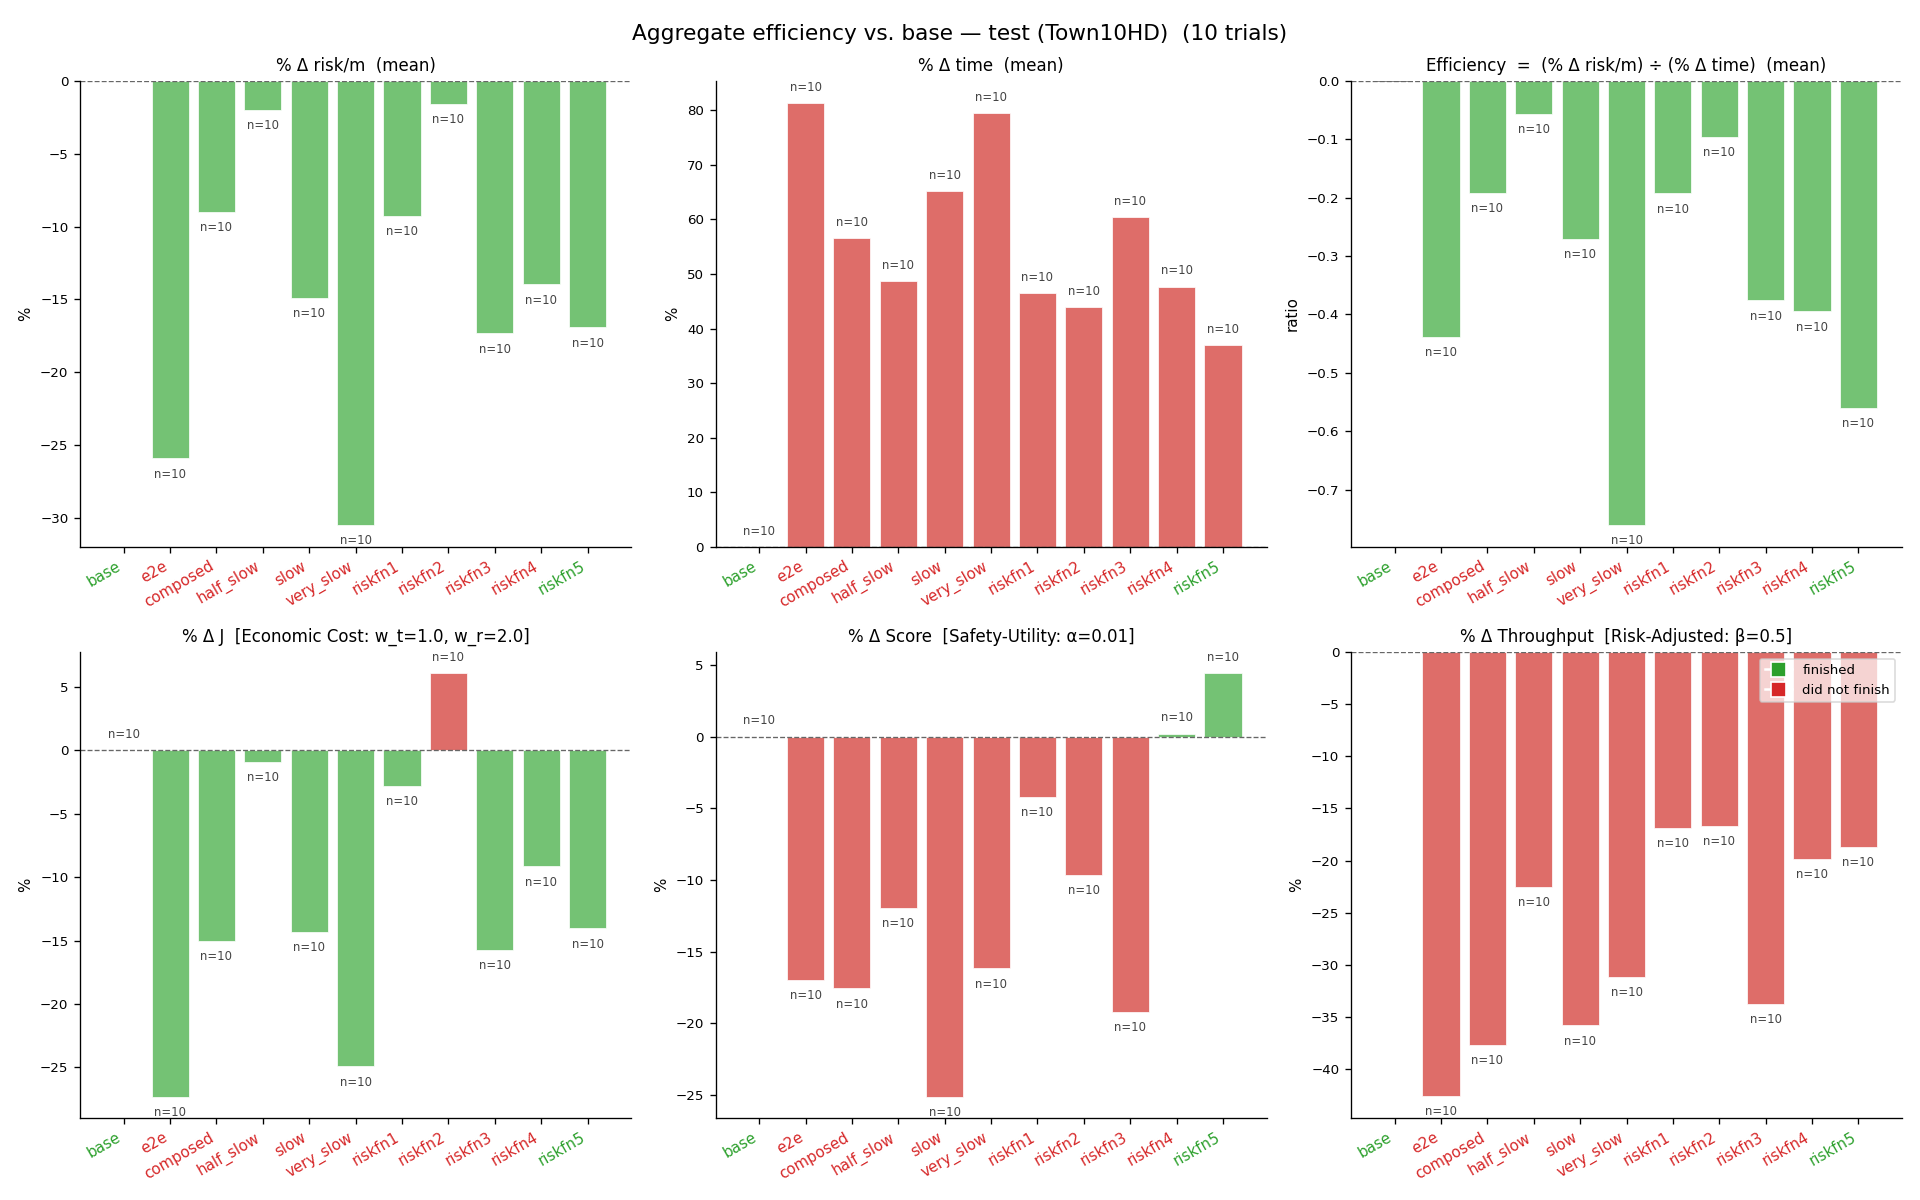

[test] 10 trials -> t:\TFG\MIREIA\trials\comparison\aggregate_efficiency_test.png


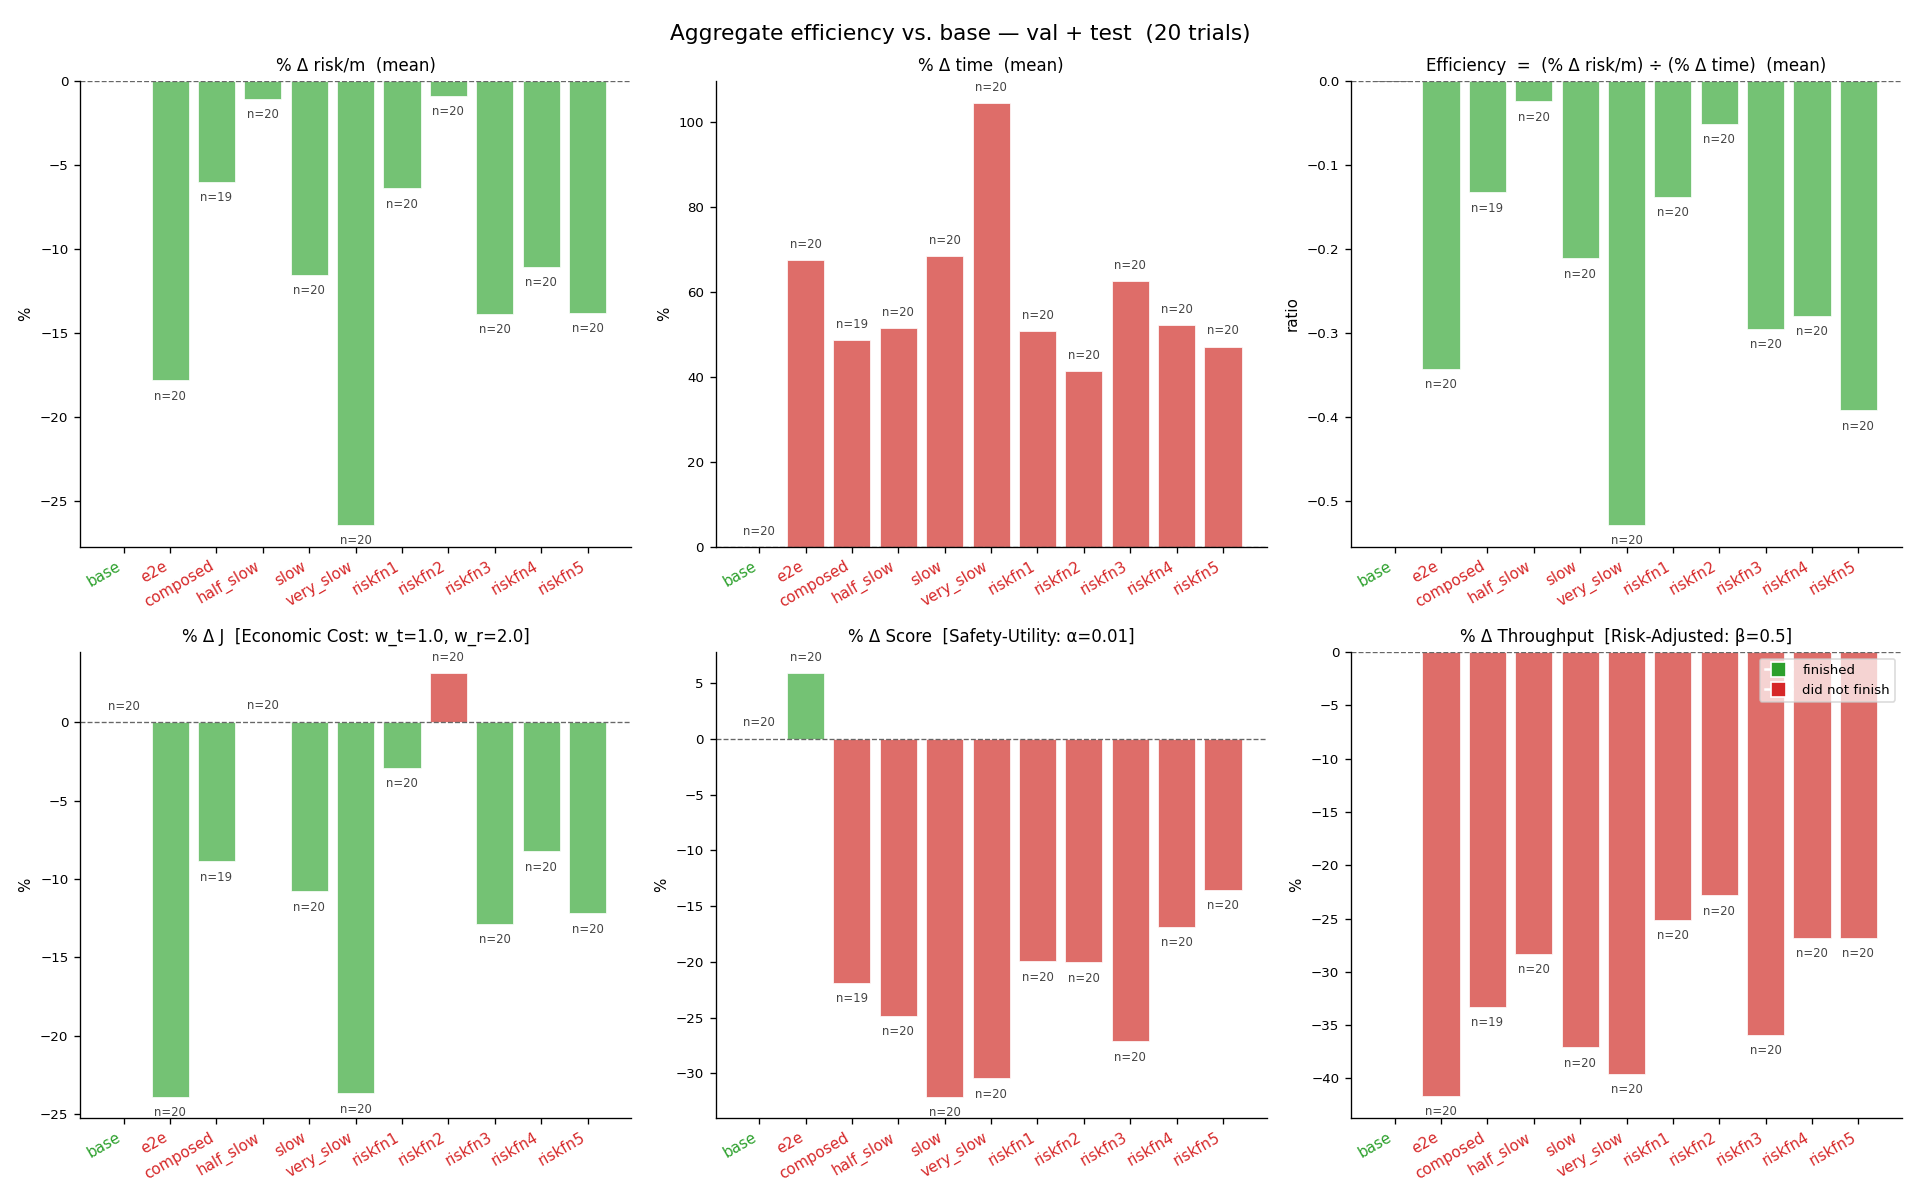

[all ] 20 trials -> t:\TFG\MIREIA\trials\comparison\aggregate_efficiency_all.png


In [9]:
import matplotlib.pyplot as plt
from IPython.display import Image

agg_dir = trials_root / 'comparison'
agg_dir.mkdir(parents=True, exist_ok=True)

AGG_FIGSIZE = (16, 10)    # same for every split

splits: list[tuple[str, dict]] = [
    ('val',  {n: r for n, r in runs_by_trial.items() if trial_split.get(n) == 'val'}),
    ('test', {n: r for n, r in runs_by_trial.items() if trial_split.get(n) == 'test'}),
    ('all',  runs_by_trial),
]

for split_name, subset in splits:
    if not subset:
        print(f'[{split_name}] no trials, skipping')
        continue
    out_path = agg_dir / f'aggregate_efficiency_{split_name}.png'
    label = {'val': 'val (Town05)', 'test': 'test (Town10HD)', 'all': 'val + test'}[split_name]
    fig = render_aggregate_efficiency_barplot(
        subset,
        title=f'Aggregate efficiency vs. base — {label}  ({len(subset)} trials)',
        output_path=out_path,
        figsize=AGG_FIGSIZE,
        w_time=W_TIME, w_risk=W_RISK, alpha=ALPHA, beta=BETA,
    )
    plt.close(fig)
    # Show the saved PNG directly — guarantees inline render matches the file on disk.
    display(Image(filename=str(out_path)))
    print(f'[{split_name:<4}] {len(subset):>2} trials -> {out_path}')

## 9 — Comparison Videos (3×3 grid)
For each trial, an MP4 with one panel per run. Every panel shows the route colored by ground-truth risk + a moving white dot at the ego's current position. Runs are synced by **route-progress fraction**, so every panel hits 100 % at the same video frame even though the runs took different sim times — the actual sim time + risk-per-meter are shown in each panel's subtitle for reference.

Toggle `RENDER_VIDEOS` to skip this step when iterating on tables / plots.

KeyboardInterrupt: 

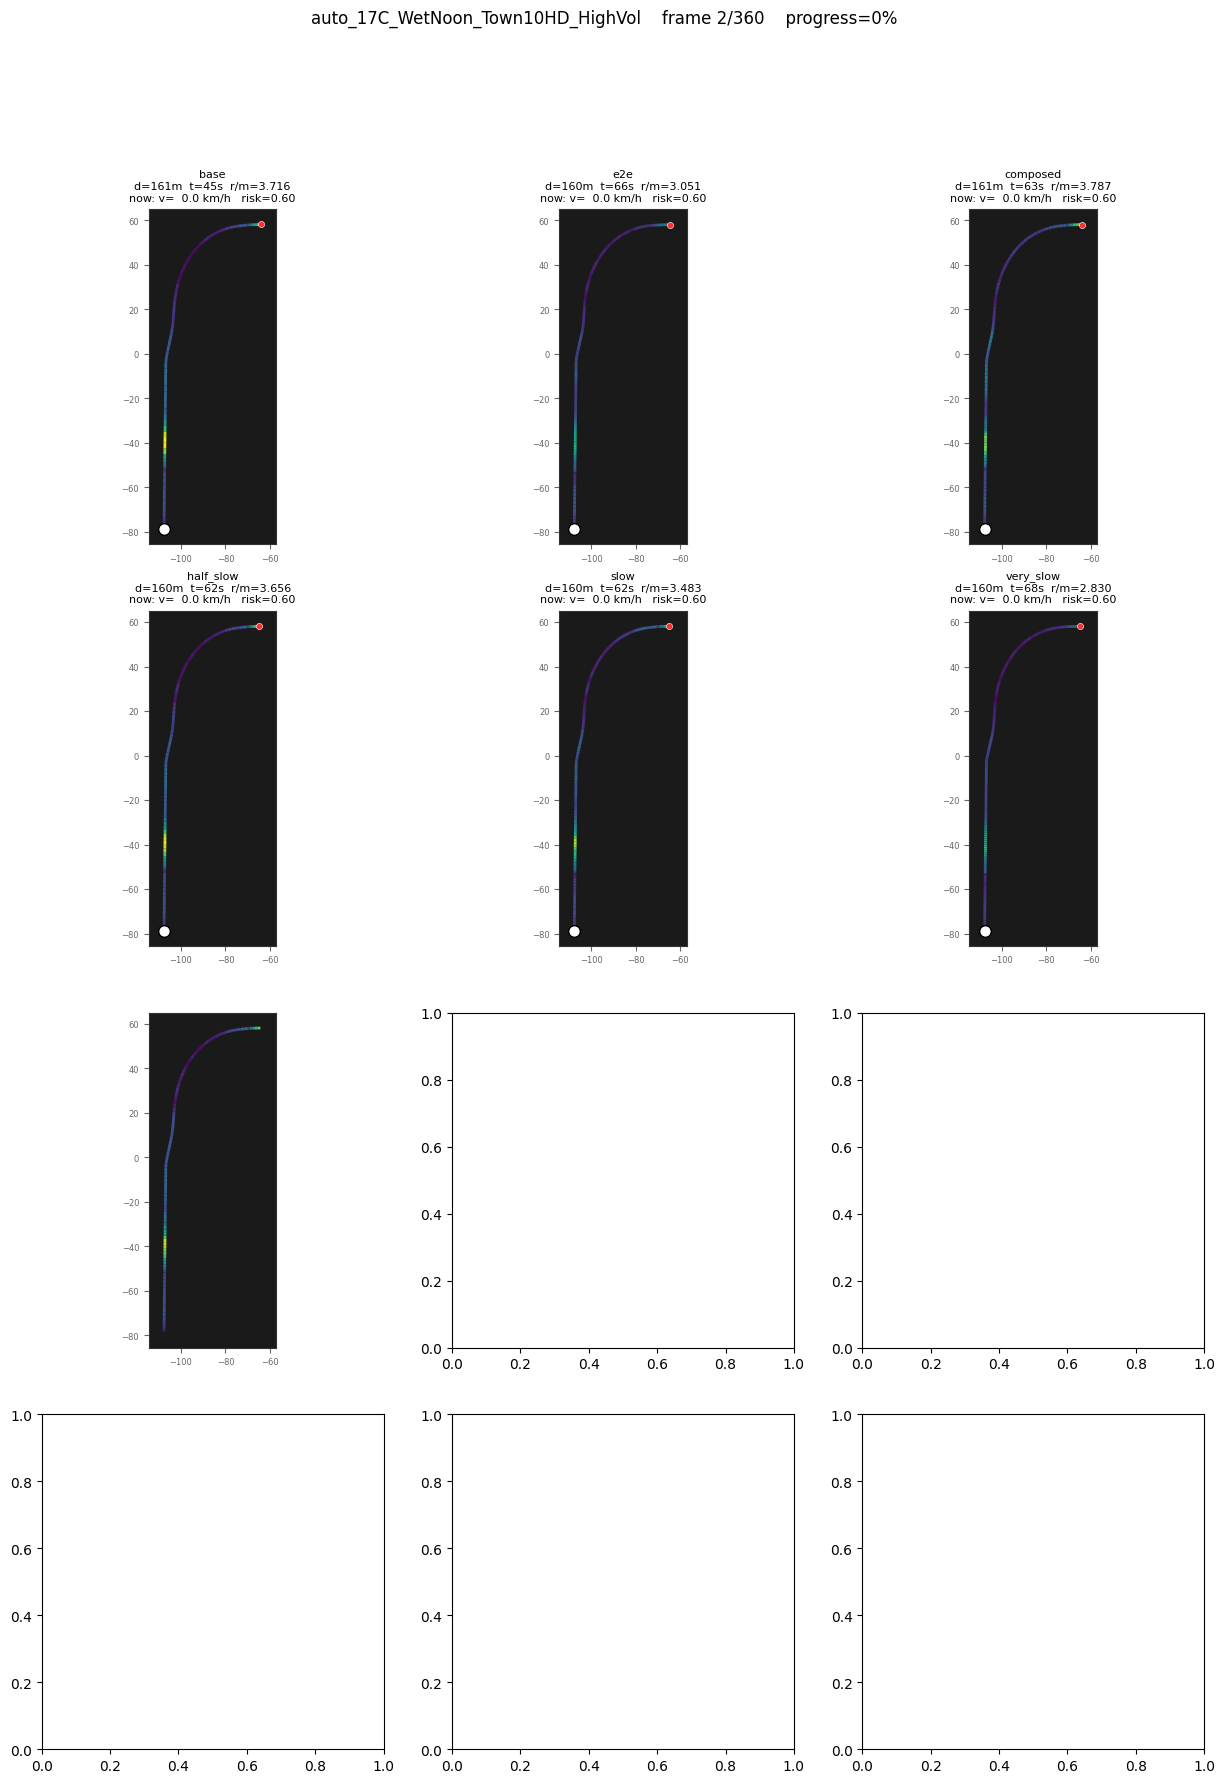

In [10]:
RENDER_VIDEOS = True          # set False if you only want the tables / static plots
VIDEO_FPS     = 8
VIDEO_SECONDS = None          # None = auto-scale to longest run (clamped 8–45s)

comparison_videos: dict[str, Path] = {}

if not RENDER_VIDEOS:
    print('RENDER_VIDEOS=False — skipping video generation.')
else:
    for tdir in selected_trial_dirs:
        cmp_dir = tdir / 'comparison'
        cmp_dir.mkdir(parents=True, exist_ok=True)
        out_path = cmp_dir / 'comparison_video.mp4'
        path = render_comparison_video(
            runs_by_trial[tdir.name],
            output_path=out_path,
            fps=VIDEO_FPS,
            video_seconds=VIDEO_SECONDS,
            title=tdir.name,
            color_by='risk_gt',
            cmap_name='viridis',
        )
        if path is None:
            print(f'{tdir.name:55s} skipped (no run has data)')
            continue
        comparison_videos[tdir.name] = path
        print(f'{tdir.name:55s} -> {path}')

# Preview the first video inline (if any).
if comparison_videos:
    first_name, first_path = next(iter(comparison_videos.items()))
    print(f'\nPreview: {first_name}')
    display(Video(str(first_path), embed=True))

## 10 — Artifact Index
Quick listing of everything this notebook produced. Re-run section 8 with `RENDER_VIDEOS=False` if you only need the tables/plots; everything else is cheap.

In [ ]:
for tdir in selected_trial_dirs:
    cmp_dir = tdir / 'comparison'
    artifacts = sorted(cmp_dir.iterdir()) if cmp_dir.exists() else []
    print(f'{tdir.name}')
    for a in artifacts:
        size_kb = a.stat().st_size / 1024.0
        print(f'  {a.name:40s}  {size_kb:8.1f} KB')

print()
print(f'Combined CSV: {trials_root / "comparison_summary.csv"}')

auto_17C_WetNoon_Town10HD_HighVol
  comparison_video.mp4                         557.0 KB
  efficiency.png                                95.5 KB
  metrics.csv                                    2.1 KB
  route_by_risk.png                            145.9 KB
  route_by_speed.png                           150.5 KB
  trial_cmp_frames_h7jugtba                      4.0 KB
auto_17D_WetNoon_Town10HD_LowVol
  comparison_video.mp4                         349.1 KB
  efficiency.png                                96.8 KB
  metrics.csv                                    2.1 KB
  route_by_risk.png                            171.6 KB
  route_by_speed.png                           180.2 KB
auto_18C_MidRainyNoon_Town10HD_HighVol
  comparison_video.mp4                         269.2 KB
  efficiency.png                                99.9 KB
  metrics.csv                                    2.2 KB
  route_by_risk.png                            155.6 KB
  route_by_speed.png                           160.7 K